In [2]:
import pandas as pd
import numpy as np


df=pd.read_csv("housing_train.csv")
df.info()
df.describe()
df.head()

<class 'pandas.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   str    
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   str    
 6   Alley          91 non-null     str    
 7   LotShape       1460 non-null   str    
 8   LandContour    1460 non-null   str    
 9   Utilities      1460 non-null   str    
 10  LotConfig      1460 non-null   str    
 11  LandSlope      1460 non-null   str    
 12  Neighborhood   1460 non-null   str    
 13  Condition1     1460 non-null   str    
 14  Condition2     1460 non-null   str    
 15  BldgType       1460 non-null   str    
 16  HouseStyle     1460 non-null   str    
 17  OverallQual    1460 non-null   int64  
 18  OverallCond    1460

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [3]:
features=["OverallQual", "GrLivArea", "LotArea", "OverallCond", "Neighborhood"]

X=df[features]
Y=df["SalePrice"]

X.info()

<class 'pandas.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   OverallQual   1460 non-null   int64
 1   GrLivArea     1460 non-null   int64
 2   LotArea       1460 non-null   int64
 3   OverallCond   1460 non-null   int64
 4   Neighborhood  1460 non-null   str  
dtypes: int64(4), str(1)
memory usage: 57.2 KB


In [5]:
X=pd.get_dummies(X, columns=["Neighborhood"], dtype=int)

X.info()

<class 'pandas.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 29 columns):
 #   Column                Non-Null Count  Dtype
---  ------                --------------  -----
 0   OverallQual           1460 non-null   int64
 1   GrLivArea             1460 non-null   int64
 2   LotArea               1460 non-null   int64
 3   OverallCond           1460 non-null   int64
 4   Neighborhood_Blmngtn  1460 non-null   int64
 5   Neighborhood_Blueste  1460 non-null   int64
 6   Neighborhood_BrDale   1460 non-null   int64
 7   Neighborhood_BrkSide  1460 non-null   int64
 8   Neighborhood_ClearCr  1460 non-null   int64
 9   Neighborhood_CollgCr  1460 non-null   int64
 10  Neighborhood_Crawfor  1460 non-null   int64
 11  Neighborhood_Edwards  1460 non-null   int64
 12  Neighborhood_Gilbert  1460 non-null   int64
 13  Neighborhood_IDOTRR   1460 non-null   int64
 14  Neighborhood_MeadowV  1460 non-null   int64
 15  Neighborhood_Mitchel  1460 non-null   int64
 16  Neighborhood_NAme

In [12]:
import sklearn as sk
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import root_mean_squared_error, r2_score

X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

model=LinearRegression()
model.fit(X_train, Y_train)
Y_pred=model.predict(X_test)

RMSE=root_mean_squared_error(Y_test, Y_pred)
R2=r2_score(Y_test, Y_pred)

print("Root Mean Squared Error:", RMSE)
print("R-squared:", R2,", ",(R2*100),"%")

Root Mean Squared Error: 37404.52798427951
R-squared: 0.8175959306116879 ,  81.75959306116879 %


Root Mean Squared Error shows how far off the predicted saleprice is from the actual saleprice. In this case, The predicted saleprice is around 37000$ off from actual price. R squared on the other hand explains that ~82% of the variation in data is explained by the columns/factors i chose.

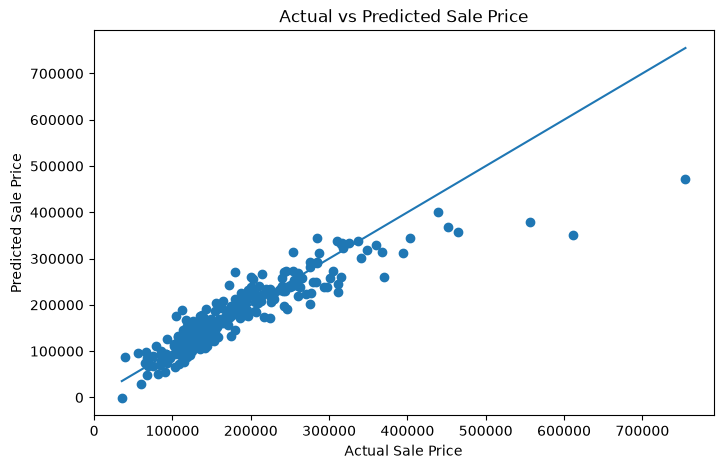

In [11]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.scatter(Y_test, Y_pred)
plt.plot([Y_test.min(), Y_test.max()], [Y_test.min(), Y_test.max()])
plt.ylabel("Predicted Sale Price")
plt.xlabel("Actual Sale Price")
plt.title("Actual vs Predicted Sale Price")
plt.show()